# Stage 0) Environment / paths / config
本 notebook 會：
1. 建立 LabelMe -> segmentation dataset  
2. 比較 6 組 loss 設定  
3. 自動挑選最佳 loss config  
4. 用最佳模型對全部原始圖推論  
5. 計算 `embryo_to_zp_ratio`  
6. 與 Excel 的 `PGT-A` / `Implantation` 合併與分析  

輸出根目錄：`/content/drive/MyDrive/論文_0409`

In [1]:

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
except Exception:
    print('[WARN] Not running in Colab or drive already mounted.')

import os
import sys
import json
import math
import time
import glob
import shutil
import random
import subprocess
from pathlib import Path
from typing import Optional, Tuple, List, Dict

def _ensure_pkg(pkg_name: str, import_name: Optional[str] = None):
    import importlib
    name = import_name or pkg_name
    try:
        importlib.import_module(name)
    except Exception:
        print(f'[INFO] Installing {pkg_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])

_ensure_pkg('albumentations')
_ensure_pkg('opencv-python', 'cv2')
_ensure_pkg('openpyxl')

import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from scipy.ndimage import binary_fill_holes
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('[INFO] DEVICE =', DEVICE)

# -------------------------
# Input paths
# -------------------------
ORI_DIR = Path('/content/drive/MyDrive/論文_new/need_label_ori')
LABEL_DIR = Path('/content/drive/MyDrive/論文_new/finish_label')
EXCEL_PATH = Path('/content/drive/MyDrive/論文_0318/image_result(combined).xlsx')

# -------------------------
# Output root
# -------------------------
ROOT_DIR = Path('/content/drive/MyDrive/論文_0422')
DATASET_DIR = ROOT_DIR / 'zp_seg_dataset_ratio'
EXPERIMENT_ROOT = ROOT_DIR / 'loss_experiments'
PRED_ROOT = ROOT_DIR / 'zp_pred_all_ratio'
MEAS_ROOT = ROOT_DIR / 'zp_measures_all_比例'
MERGE_ROOT = ROOT_DIR / 'clinical_compare_ratio'

IMG_DIR = DATASET_DIR / 'images'
ZP_MASK_DIR = DATASET_DIR / 'masks_zp_inner'
EMBRYO_MASK_DIR = DATASET_DIR / 'masks_embryo_outer'
FIG_DIR = DATASET_DIR / 'figures'
VAL_PRED_DIR = DATASET_DIR / 'pred_overlay_val'

PRED_ZP_DIR = PRED_ROOT / 'masks_zp_inner'
PRED_EMB_DIR = PRED_ROOT / 'masks_embryo_outer'
PRED_OVERLAY_DIR = PRED_ROOT / 'overlay'

ZP_CLEAN_DIR = MEAS_ROOT / 'zp_inner_closed_fill_比例'
EMB_CLEAN_DIR = MEAS_ROOT / 'embryo_outer_closed_fill_main_比例'
RATIO_OVERLAY_DIR = MEAS_ROOT / 'overlay_area_ratio_比例'

for d in [
    ROOT_DIR, DATASET_DIR, EXPERIMENT_ROOT, PRED_ROOT, MEAS_ROOT, MERGE_ROOT,
    IMG_DIR, ZP_MASK_DIR, EMBRYO_MASK_DIR, FIG_DIR, VAL_PRED_DIR,
    PRED_ZP_DIR, PRED_EMB_DIR, PRED_OVERLAY_DIR,
    ZP_CLEAN_DIR, EMB_CLEAN_DIR, RATIO_OVERLAY_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

print('[INFO] ORI_DIR   =', ORI_DIR)
print('[INFO] LABEL_DIR =', LABEL_DIR)
print('[INFO] EXCEL     =', EXCEL_PATH)
print('[INFO] ROOT_DIR  =', ROOT_DIR)

# -------------------------
# Config
# -------------------------
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
ZP_LABEL_CANDIDATES = ['zp_inner']
EMBRYO_LABEL_CANDIDATES = ['embryo_outer', 'embryo_outter']

IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2
EPOCHS = 80
LR = 1e-3
VAL_RATIO = 0.2
THRESH = 0.5

CLEAR_OLD_OUTPUT = False   # 若要每次重建 dataset，可改 True
ZP_CLOSE_KSIZE = 9
EMBRYO_CLOSE_KSIZE = 9

# -------------------------
# Loss experiment configs
# -------------------------
LOSS_CONFIGS = [
    {'name': 'BCE',                        'kind': 'bce'},
    {'name': 'Dice',                       'kind': 'dice'},
    {'name': 'BCE_Dice',                   'kind': 'bce_dice'},
    {'name': 'BCE_Dice_Boundary',          'kind': 'bce_dice_boundary'},
    {'name': 'BCE_Dice_Focal',             'kind': 'bce_dice_focal'},
    {'name': 'Adaptive_BCE_Dice_Boundary', 'kind': 'adaptive_bce_dice_boundary'},
]

print('[INFO] LOSS_CONFIGS =', [x['name'] for x in LOSS_CONFIGS])


Mounted at /content/drive
[INFO] DEVICE = cuda
[INFO] ORI_DIR   = /content/drive/MyDrive/論文_new/need_label_ori
[INFO] LABEL_DIR = /content/drive/MyDrive/論文_new/finish_label
[INFO] EXCEL     = /content/drive/MyDrive/論文_0318/image_result(combined).xlsx
[INFO] ROOT_DIR  = /content/drive/MyDrive/論文_0422
[INFO] LOSS_CONFIGS = ['BCE', 'Dice', 'BCE_Dice', 'BCE_Dice_Boundary', 'BCE_Dice_Focal', 'Adaptive_BCE_Dice_Boundary']


## Stage 1) Build labeled list from `LABEL_DIR/*.json`

In [2]:

def find_image_by_stem_recursive(stem: str, ori_dir: Path) -> Optional[Path]:
    hits = []
    for ext in IMG_EXTS:
        hits.extend(ori_dir.rglob(f'{stem}{ext}'))
        hits.extend(ori_dir.rglob(f'{stem}{ext.upper()}'))
    hits = sorted(set(hits))
    if len(hits) == 0:
        return None
    if len(hits) > 1:
        print(f'[WARN] Multiple images for stem={stem}, use first: {hits[0]}')
    return hits[0]

json_files = sorted(LABEL_DIR.rglob('*.json'))
rows = []
for jp in tqdm(json_files, desc='scan json'):
    stem = jp.stem
    imgp = find_image_by_stem_recursive(stem, ORI_DIR)
    rows.append({
        'stem': stem,
        'json_path': str(jp),
        'image_path': '' if imgp is None else str(imgp),
        'matched': imgp is not None,
    })

meta_df = pd.DataFrame(rows)
meta_csv = DATASET_DIR / 'labeled_meta.csv'
meta_df.to_csv(meta_csv, index=False, encoding='utf-8-sig')

print('[INFO] total json =', len(meta_df))
print('[INFO] matched    =', int(meta_df['matched'].sum()))
display(meta_df.head())
print('[SAVED]', meta_csv)


scan json:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] total json = 100
[INFO] matched    = 100


,stem,json_path,image_path,matched
0,1DD-D5(BEFORE5-4C)-20210502102450,/content/drive/MyDrive/論文_new/finish_label/1DD...,/content/drive/MyDrive/論文_new/need_label_ori/1...,True
1,2BB-D5(BEFORE2-6C)-20210202155045,/content/drive/MyDrive/論文_new/finish_label/2BB...,/content/drive/MyDrive/論文_new/need_label_ori/2...,True
2,2BB-D5(BEFORE4-4C)-20200414152103,/content/drive/MyDrive/論文_new/finish_label/2BB...,/content/drive/MyDrive/論文_new/need_label_ori/2...,True
3,2BB-D5(BEFORE7-3C)-20180716154108,/content/drive/MyDrive/論文_new/finish_label/2BB...,/content/drive/MyDrive/論文_new/need_label_ori/2...,True
4,2BB-D5(BEFORE9-1C)-20190910163556,/content/drive/MyDrive/論文_new/finish_label/2BB...,/content/drive/MyDrive/論文_new/need_label_ori/2...,True


[SAVED] /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/labeled_meta.csv


## Stage 2) LabelMe -> segmentation masks

In [3]:

if CLEAR_OLD_OUTPUT:
    for d in [IMG_DIR, ZP_MASK_DIR, EMBRYO_MASK_DIR]:
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)

def polygon_area(points):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) < 3:
        return 0.0
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def choose_largest_shape(shapes, label_candidates):
    keep = []
    label_candidates_lc = [x.lower() for x in label_candidates]
    for s in shapes:
        lb = str(s.get('label', '')).strip().lower()
        if lb in label_candidates_lc and s.get('shape_type', 'polygon') == 'polygon':
            pts = s.get('points', [])
            keep.append((polygon_area(pts), s))
    if not keep:
        return None
    keep.sort(key=lambda x: x[0], reverse=True)
    return keep[0][1]

def shape_to_mask(size_wh, points):
    w, h = size_wh
    img = Image.new('L', (w, h), 0)
    drw = ImageDraw.Draw(img)
    xy = [tuple(map(float, p)) for p in points]
    drw.polygon(xy, outline=1, fill=1)
    return np.array(img, dtype=np.uint8)

matched_df = meta_df[meta_df['matched']].copy().reset_index(drop=True)
ok_rows = []

for _, r in tqdm(matched_df.iterrows(), total=len(matched_df), desc='labelme->mask'):
    jp = Path(r['json_path'])
    ip = Path(r['image_path'])
    try:
        with open(jp, 'r', encoding='utf-8') as f:
            obj = json.load(f)

        img = cv2.imread(str(ip), cv2.IMREAD_COLOR)
        if img is None:
            raise RuntimeError(f'cv2.imread failed: {ip}')
        h, w = img.shape[:2]

        shapes = obj.get('shapes', [])
        zp_shape = choose_largest_shape(shapes, ZP_LABEL_CANDIDATES)
        emb_shape = choose_largest_shape(shapes, EMBRYO_LABEL_CANDIDATES)
        if (zp_shape is None) or (emb_shape is None):
            continue

        zp_mask = shape_to_mask((w, h), zp_shape['points'])
        emb_mask = shape_to_mask((w, h), emb_shape['points'])

        out_img = IMG_DIR / f'{ip.stem}.png'
        out_zp = ZP_MASK_DIR / f'{ip.stem}.png'
        out_emb = EMBRYO_MASK_DIR / f'{ip.stem}.png'

        cv2.imwrite(str(out_img), img)
        cv2.imwrite(str(out_zp), (zp_mask * 255).astype(np.uint8))
        cv2.imwrite(str(out_emb), (emb_mask * 255).astype(np.uint8))

        ok_rows.append({'stem': ip.stem, 'image': out_img.name, 'zp_mask': out_zp.name, 'embryo_mask': out_emb.name})
    except Exception as e:
        print('[WARN]', jp.name, '->', e)

usable_df = pd.DataFrame(ok_rows)
usable_csv = DATASET_DIR / 'usable_pairs.csv'
usable_df.to_csv(usable_csv, index=False, encoding='utf-8-sig')
print('[INFO] usable labeled pairs =', len(usable_df))
print('[SAVED]', usable_csv)
display(usable_df.head())


labelme->mask:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] usable labeled pairs = 100
[SAVED] /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/usable_pairs.csv


,stem,image,zp_mask,embryo_mask
0,1DD-D5(BEFORE5-4C)-20210502102450,1DD-D5(BEFORE5-4C)-20210502102450.png,1DD-D5(BEFORE5-4C)-20210502102450.png,1DD-D5(BEFORE5-4C)-20210502102450.png
1,2BB-D5(BEFORE2-6C)-20210202155045,2BB-D5(BEFORE2-6C)-20210202155045.png,2BB-D5(BEFORE2-6C)-20210202155045.png,2BB-D5(BEFORE2-6C)-20210202155045.png
2,2BB-D5(BEFORE4-4C)-20200414152103,2BB-D5(BEFORE4-4C)-20200414152103.png,2BB-D5(BEFORE4-4C)-20200414152103.png,2BB-D5(BEFORE4-4C)-20200414152103.png
3,2BB-D5(BEFORE7-3C)-20180716154108,2BB-D5(BEFORE7-3C)-20180716154108.png,2BB-D5(BEFORE7-3C)-20180716154108.png,2BB-D5(BEFORE7-3C)-20180716154108.png
4,2BB-D5(BEFORE9-1C)-20190910163556,2BB-D5(BEFORE9-1C)-20190910163556.png,2BB-D5(BEFORE9-1C)-20190910163556.png,2BB-D5(BEFORE9-1C)-20190910163556.png


## Stage 3) train / val split

In [4]:

img_files = sorted([p for p in IMG_DIR.glob('*') if p.is_file()])
zp_files = sorted([p for p in ZP_MASK_DIR.glob('*.png') if p.is_file()])
emb_files = sorted([p for p in EMBRYO_MASK_DIR.glob('*.png') if p.is_file()])

img_map = {p.stem: p.name for p in img_files}
zp_map = {p.stem: p.name for p in zp_files}
emb_map = {p.stem: p.name for p in emb_files}

common = sorted(set(img_map) & set(zp_map) & set(emb_map))
split_df = pd.DataFrame({
    'stem': common,
    'image': [img_map[s] for s in common],
    'zp_mask': [zp_map[s] for s in common],
    'embryo_mask': [emb_map[s] for s in common],
})

train_stems, val_stems = train_test_split(split_df['stem'].tolist(), test_size=VAL_RATIO, random_state=SEED, shuffle=True)
split_df['split'] = split_df['stem'].map(lambda x: 'val' if x in set(val_stems) else 'train')

split_csv = DATASET_DIR / 'split.csv'
split_df.to_csv(split_csv, index=False, encoding='utf-8-sig')

print('[INFO] split_df =', split_df.shape)
print(split_df['split'].value_counts())
display(split_df.head())
print('[SAVED]', split_csv)


[INFO] split_df = (100, 5)
split
train    80
val      20
Name: count, dtype: int64


,stem,image,zp_mask,embryo_mask,split
0,1DD-D5(BEFORE5-4C)-20210502102450,1DD-D5(BEFORE5-4C)-20210502102450.png,1DD-D5(BEFORE5-4C)-20210502102450.png,1DD-D5(BEFORE5-4C)-20210502102450.png,val
1,2BB-D5(BEFORE2-6C)-20210202155045,2BB-D5(BEFORE2-6C)-20210202155045.png,2BB-D5(BEFORE2-6C)-20210202155045.png,2BB-D5(BEFORE2-6C)-20210202155045.png,train
2,2BB-D5(BEFORE4-4C)-20200414152103,2BB-D5(BEFORE4-4C)-20200414152103.png,2BB-D5(BEFORE4-4C)-20200414152103.png,2BB-D5(BEFORE4-4C)-20200414152103.png,train
3,2BB-D5(BEFORE7-3C)-20180716154108,2BB-D5(BEFORE7-3C)-20180716154108.png,2BB-D5(BEFORE7-3C)-20180716154108.png,2BB-D5(BEFORE7-3C)-20180716154108.png,train
4,2BB-D5(BEFORE9-1C)-20190910163556,2BB-D5(BEFORE9-1C)-20190910163556.png,2BB-D5(BEFORE9-1C)-20190910163556.png,2BB-D5(BEFORE9-1C)-20190910163556.png,val


[SAVED] /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/split.csv


## Stage 4) Dataset + DataLoader

讀原圖
讀 zp mask 和 embryo mask
resize 到固定大小

組成 2-channel target
training 時加 augmentation

In [5]:

# 這裡用了 albumentations，包括：

# Resize
# HorizontalFlip
# VerticalFlip
# Rotate
# RandomBrightnessContrast
# ShiftScaleRotate

class ZPSegDataset(Dataset):
    def __init__(self, split_csv: Path, split_name: str, img_dir: Path, zp_dir: Path, emb_dir: Path,
                 img_size: int = 256, augment: bool = False):
        self.df = pd.read_csv(split_csv)
        self.df = self.df[self.df['split'] == split_name].copy().reset_index(drop=True)
        self.img_dir = img_dir
        self.zp_dir = zp_dir
        self.emb_dir = emb_dir
        self.img_size = img_size
        self.augment = augment

        self.tf = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=20, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=10,
                               border_mode=cv2.BORDER_REFLECT_101, p=0.3),
        ], additional_targets={'mask2': 'mask'})

        self.tf_noaug = A.Compose([
            A.Resize(img_size, img_size)
        ], additional_targets={'mask2': 'mask'})

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        stem = r['stem']

        img = cv2.imread(str(self.img_dir / r['image']), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        zp = cv2.imread(str(self.zp_dir / r['zp_mask']), cv2.IMREAD_GRAYSCALE)
        emb = cv2.imread(str(self.emb_dir / r['embryo_mask']), cv2.IMREAD_GRAYSCALE)

        zp = (zp > 127).astype(np.uint8)
        emb = (emb > 127).astype(np.uint8)

        if self.augment:
            aug = self.tf(image=img, mask=zp, mask2=emb)
        else:
            aug = self.tf_noaug(image=img, mask=zp, mask2=emb)

        img = aug['image'].astype(np.float32) / 255.0
        zp = aug['mask'].astype(np.float32)
        emb = aug['mask2'].astype(np.float32)

        img = np.transpose(img, (2, 0, 1))
        y = np.stack([zp, emb], axis=0)

        return torch.from_numpy(img), torch.from_numpy(y), stem

train_ds = ZPSegDataset(split_csv, 'train', IMG_DIR, ZP_MASK_DIR, EMBRYO_MASK_DIR, img_size=IMG_SIZE, augment=True)
val_ds   = ZPSegDataset(split_csv, 'val', IMG_DIR, ZP_MASK_DIR, EMBRYO_MASK_DIR, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('[INFO] train =', len(train_ds), 'val =', len(val_ds))


[INFO] train = 80 val = 20


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Stage 5) U-Net model

輸入：3-channel RGB image

輸出：2-channel logits
一個預測 ZP
一個預測 embryo

In [6]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mpconv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )
    def forward(self, x):
        return self.mpconv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=2, base_c=32):
        super().__init__()
        self.inc = DoubleConv(n_channels, base_c)
        self.down1 = Down(base_c, base_c * 2)
        self.down2 = Down(base_c * 2, base_c * 4)
        self.down3 = Down(base_c * 4, base_c * 8)
        self.down4 = Down(base_c * 8, base_c * 8)
        self.up1 = Up(base_c * 16, base_c * 4)
        self.up2 = Up(base_c * 8, base_c * 2)
        self.up3 = Up(base_c * 4, base_c)
        self.up4 = Up(base_c * 2, base_c)
        self.outc = nn.Conv2d(base_c, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

model = UNet(n_channels=3, n_classes=2).to(DEVICE)
print(sum(p.numel() for p in model.parameters()) / 1e6, 'M params')


3.350306 M params


## Stage 6) Losses / metrics / experiment utilities

In [7]:

# -------------------------
# Metrics
# -------------------------
def dice_score(prob: torch.Tensor, target: torch.Tensor, eps: float = 1e-7):
    prob = (prob > THRESH).float()
    inter = (prob * target).sum(dim=(1, 2))
    den = prob.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    return ((2 * inter + eps) / (den + eps)).mean()

def iou_score(prob: torch.Tensor, target: torch.Tensor, eps: float = 1e-7):
    prob = (prob > THRESH).float()
    inter = (prob * target).sum(dim=(1, 2))
    union = prob.sum(dim=(1, 2)) + target.sum(dim=(1, 2)) - inter
    return ((inter + eps) / (union + eps)).mean()

# -------------------------
# Atomic losses
# -------------------------
bce_loss_fn = nn.BCEWithLogitsLoss()

def dice_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-7):
    prob = torch.sigmoid(logits)
    inter = (prob * target).sum(dim=(2, 3))
    den = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2 * inter + eps) / (den + eps)
    return 1.0 - dice.mean()

def focal_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, alpha: float = 0.25, gamma: float = 2.0):
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    prob = torch.sigmoid(logits)
    p_t = prob * target + (1 - prob) * (1 - target)
    alpha_factor = alpha * target + (1 - alpha) * (1 - target)
    modulating = (1 - p_t) ** gamma
    return (alpha_factor * modulating * bce).mean()

def _sobel_kernels(device, dtype):
    kx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=dtype, device=device).view(1, 1, 3, 3)
    ky = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=dtype, device=device).view(1, 1, 3, 3)
    return kx, ky

def _edge_map(x: torch.Tensor):
    # x: [B, C, H, W]
    B, C, H, W = x.shape
    kx, ky = _sobel_kernels(x.device, x.dtype)
    kx = kx.repeat(C, 1, 1, 1)
    ky = ky.repeat(C, 1, 1, 1)
    gx = F.conv2d(x, kx, padding=1, groups=C)
    gy = F.conv2d(x, ky, padding=1, groups=C)
    g = torch.sqrt(gx * gx + gy * gy + 1e-6)
    return g

def boundary_loss_from_logits(logits: torch.Tensor, target: torch.Tensor):
    prob = torch.sigmoid(logits)
    pred_edge = _edge_map(prob)
    tgt_edge = _edge_map(target)
    pred_edge = pred_edge / (pred_edge.amax(dim=(2, 3), keepdim=True) + 1e-6)
    tgt_edge = tgt_edge / (tgt_edge.amax(dim=(2, 3), keepdim=True) + 1e-6)
    return F.l1_loss(pred_edge, tgt_edge)

# -------------------------
# Adaptive loss module
# -------------------------
class AdaptiveCompositeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.logits_w = nn.Parameter(torch.zeros(3, dtype=torch.float32))  # BCE, Dice, Boundary

    def forward(self, logits: torch.Tensor, target: torch.Tensor):
        l_bce = bce_loss_fn(logits, target)
        l_dice = dice_loss_from_logits(logits, target)
        l_boundary = boundary_loss_from_logits(logits, target)
        raw = torch.stack([l_bce, l_dice, l_boundary])
        w = torch.softmax(self.logits_w, dim=0)
        total = (w * raw).sum()
        info = {
            'w_bce': float(w[0].detach().cpu()),
            'w_dice': float(w[1].detach().cpu()),
            'w_boundary': float(w[2].detach().cpu()),
            'loss_bce': float(l_bce.detach().cpu()),
            'loss_dice': float(l_dice.detach().cpu()),
            'loss_boundary': float(l_boundary.detach().cpu()),
        }
        return total, info

def compute_total_loss(kind: str, logits: torch.Tensor, target: torch.Tensor, adaptive_module: Optional[nn.Module] = None):
    if kind == 'bce':
        total = bce_loss_fn(logits, target)
        info = {'loss_bce': float(total.detach().cpu())}
        return total, info

    if kind == 'dice':
        total = dice_loss_from_logits(logits, target)
        info = {'loss_dice': float(total.detach().cpu())}
        return total, info

    if kind == 'bce_dice':
        l_bce = bce_loss_fn(logits, target)
        l_dice = dice_loss_from_logits(logits, target)
        total = 0.5 * l_bce + 0.5 * l_dice
        info = {'loss_bce': float(l_bce.detach().cpu()), 'loss_dice': float(l_dice.detach().cpu())}
        return total, info

    if kind == 'bce_dice_boundary':
        l_bce = bce_loss_fn(logits, target)
        l_dice = dice_loss_from_logits(logits, target)
        l_boundary = boundary_loss_from_logits(logits, target)
        total = 0.4 * l_bce + 0.4 * l_dice + 0.2 * l_boundary
        info = {
            'loss_bce': float(l_bce.detach().cpu()),
            'loss_dice': float(l_dice.detach().cpu()),
            'loss_boundary': float(l_boundary.detach().cpu()),
        }
        return total, info

    if kind == 'bce_dice_focal':
        l_bce = bce_loss_fn(logits, target)
        l_dice = dice_loss_from_logits(logits, target)
        l_focal = focal_loss_from_logits(logits, target)
        total = 0.4 * l_bce + 0.4 * l_dice + 0.2 * l_focal
        info = {
            'loss_bce': float(l_bce.detach().cpu()),
            'loss_dice': float(l_dice.detach().cpu()),
            'loss_focal': float(l_focal.detach().cpu()),
        }
        return total, info

    if kind == 'adaptive_bce_dice_boundary':
        assert adaptive_module is not None
        return adaptive_module(logits, target)

    raise ValueError(f'Unknown loss kind: {kind}')

@torch.no_grad()
def evaluate(model: nn.Module, loader, kind: str, adaptive_module: Optional[nn.Module] = None):
    model.eval()
    if adaptive_module is not None:
        adaptive_module.eval()

    loss_sum = 0.0
    nb = 0

    dz_list, de_list, dm_list = [], [], []
    iz_list, ie_list, im_list = [], [], []

    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss, _ = compute_total_loss(kind, logits, y, adaptive_module=adaptive_module)

        prob = torch.sigmoid(logits)
        dz = dice_score(prob[:, 0], y[:, 0]).item()
        de = dice_score(prob[:, 1], y[:, 1]).item()
        iz = iou_score(prob[:, 0], y[:, 0]).item()
        ie = iou_score(prob[:, 1], y[:, 1]).item()

        loss_sum += loss.item()
        nb += 1

        dz_list.append(dz)
        de_list.append(de)
        dm_list.append((dz + de) / 2)
        iz_list.append(iz)
        ie_list.append(ie)
        im_list.append((iz + ie) / 2)

    return {
        'val_loss': loss_sum / max(nb, 1),
        'dice_zp': float(np.mean(dz_list)) if dz_list else np.nan,
        'dice_emb': float(np.mean(de_list)) if de_list else np.nan,
        'dice_mean': float(np.mean(dm_list)) if dm_list else np.nan,
        'iou_zp': float(np.mean(iz_list)) if iz_list else np.nan,
        'iou_emb': float(np.mean(ie_list)) if ie_list else np.nan,
        'iou_mean': float(np.mean(im_list)) if im_list else np.nan,
    }


## Stage 7)訓練 6 組 loss

bce

dice

bce_dice

bce_dice_boundary

bce_dice_focal

adaptive_bce_dice_boundary

每個實驗都會：

建一個新 U-Net
設 optimizer = AdamW
訓練 EPOCHS=80
每個 epoch 跑 validation
用 dice_mean 選最佳 checkpoint
存 train log、curve、ckpt




最佳模型判定標準是：

metrics['dice_mean'] > best_dice
，也就是用
(ZP Dice + embryo Dice) / 2
作為 loss config 排名依據。

In [8]:

def plot_history(history_df: pd.DataFrame, save_dir: Path, title_prefix: str):
    save_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
    plt.plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(f'{title_prefix} - loss curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / 'loss_curve.png', dpi=180)
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df['epoch'], history_df['dice_zp'], label='dice_zp')
    plt.plot(history_df['epoch'], history_df['dice_emb'], label='dice_emb')
    plt.plot(history_df['epoch'], history_df['dice_mean'], label='dice_mean')
    plt.xlabel('epoch')
    plt.ylabel('dice')
    plt.title(f'{title_prefix} - dice curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / 'dice_curve.png', dpi=180)
    plt.close()

def train_one_experiment(cfg: Dict):
    exp_name = cfg['name']
    kind = cfg['kind']
    exp_dir = EXPERIMENT_ROOT / exp_name
    ckpt_dir = exp_dir / 'checkpoints'
    fig_dir = exp_dir / 'figures'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    fig_dir.mkdir(parents=True, exist_ok=True)

    model = UNet(n_channels=3, n_classes=2).to(DEVICE)
    adaptive_module = AdaptiveCompositeLoss().to(DEVICE) if kind == 'adaptive_bce_dice_boundary' else None

    params = list(model.parameters())
    if adaptive_module is not None:
        params += list(adaptive_module.parameters())

    optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=1e-4)

    best_ckpt = ckpt_dir / 'unet_best.pt'
    last_ckpt = ckpt_dir / 'unet_last.pt'
    history = []
    best_dice = -1.0
    best_epoch = -1

    print(f'\n===== TRAIN START: {exp_name} =====')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        if adaptive_module is not None:
            adaptive_module.train()

        t0 = time.time()
        train_loss_sum = 0.0
        nb = 0

        running_info = []

        for x, y, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss, info = compute_total_loss(kind, logits, y, adaptive_module=adaptive_module)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            nb += 1
            running_info.append(info)

        metrics = evaluate(model, val_loader, kind, adaptive_module=adaptive_module)
        train_loss = train_loss_sum / max(nb, 1)

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            **metrics
        }

        if adaptive_module is not None and running_info:
            w = torch.softmax(adaptive_module.logits_w.detach().cpu(), dim=0).numpy()
            row['w_bce'] = float(w[0])
            row['w_dice'] = float(w[1])
            row['w_boundary'] = float(w[2])

        history.append(row)
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'cfg': cfg,
            'adaptive_state_dict': None if adaptive_module is None else adaptive_module.state_dict(),
        }, last_ckpt)

        if metrics['dice_mean'] > best_dice:
            best_dice = metrics['dice_mean']
            best_epoch = epoch
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'cfg': cfg,
                'adaptive_state_dict': None if adaptive_module is None else adaptive_module.state_dict(),
            }, best_ckpt)

        dt = time.time() - t0
        extra = ''
        if adaptive_module is not None and running_info:
            extra = f" | w=[{row['w_bce']:.3f}, {row['w_dice']:.3f}, {row['w_boundary']:.3f}]"
        print(
            f"[{exp_name}] Epoch {epoch:03d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={metrics['val_loss']:.4f} | "
            f"dice_zp={metrics['dice_zp']:.4f} | dice_emb={metrics['dice_emb']:.4f} | "
            f"dice_mean={metrics['dice_mean']:.4f} | {dt:.1f}s{extra}"
        )

    hist_df = pd.DataFrame(history)
    hist_csv = exp_dir / 'train_log.csv'
    hist_df.to_csv(hist_csv, index=False, encoding='utf-8-sig')
    plot_history(hist_df, fig_dir, exp_name)

    result = {
        'experiment': exp_name,
        'kind': kind,
        'best_epoch': best_epoch,
        'best_dice_mean': best_dice,
        'best_ckpt': str(best_ckpt),
        'last_ckpt': str(last_ckpt),
        'history_csv': str(hist_csv),
    }

    if adaptive_module is not None:
        ckpt = torch.load(best_ckpt, map_location='cpu')
        temp = AdaptiveCompositeLoss()
        temp.load_state_dict(ckpt['adaptive_state_dict'])
        w = torch.softmax(temp.logits_w.detach(), dim=0).numpy()
        result['best_w_bce'] = float(w[0])
        result['best_w_dice'] = float(w[1])
        result['best_w_boundary'] = float(w[2])

    return result

all_results = []
for cfg in LOSS_CONFIGS:
    res = train_one_experiment(cfg)
    all_results.append(res)

results_df = pd.DataFrame(all_results).sort_values('best_dice_mean', ascending=False).reset_index(drop=True)
results_csv = EXPERIMENT_ROOT / 'loss_experiment_summary.csv'
results_df.to_csv(results_csv, index=False, encoding='utf-8-sig')

print('\n===== ALL EXPERIMENTS DONE =====')
display(results_df)
print('[SAVED]', results_csv)

best_row = results_df.iloc[0].to_dict()
BEST_EXPERIMENT_NAME = best_row['experiment']
BEST_KIND = best_row['kind']
BEST_CKPT = Path(best_row['best_ckpt'])

print('[INFO] BEST_EXPERIMENT_NAME =', BEST_EXPERIMENT_NAME)
print('[INFO] BEST_KIND            =', BEST_KIND)
print('[INFO] BEST_CKPT            =', BEST_CKPT)



===== TRAIN START: BCE =====
[BCE] Epoch 001/80 | train_loss=0.6216 | val_loss=0.6537 | dice_zp=0.0000 | dice_emb=0.0731 | dice_mean=0.0366 | 7.3s
[BCE] Epoch 002/80 | train_loss=0.5051 | val_loss=0.4795 | dice_zp=0.0000 | dice_emb=0.0151 | dice_mean=0.0075 | 1.9s
[BCE] Epoch 003/80 | train_loss=0.4631 | val_loss=0.4049 | dice_zp=0.0000 | dice_emb=0.0247 | dice_mean=0.0124 | 1.9s
[BCE] Epoch 004/80 | train_loss=0.4144 | val_loss=0.3768 | dice_zp=0.0000 | dice_emb=0.0258 | dice_mean=0.0129 | 1.9s
[BCE] Epoch 005/80 | train_loss=0.3795 | val_loss=0.3468 | dice_zp=0.0000 | dice_emb=0.0297 | dice_mean=0.0149 | 1.9s
[BCE] Epoch 006/80 | train_loss=0.3489 | val_loss=0.3511 | dice_zp=0.0489 | dice_emb=0.1669 | dice_mean=0.1079 | 1.9s
[BCE] Epoch 007/80 | train_loss=0.3212 | val_loss=0.3491 | dice_zp=0.1360 | dice_emb=0.2258 | dice_mean=0.1809 | 1.9s
[BCE] Epoch 008/80 | train_loss=0.2915 | val_loss=0.4928 | dice_zp=0.4174 | dice_emb=0.0332 | dice_mean=0.2253 | 2.0s
[BCE] Epoch 009/80 | train

,experiment,kind,best_epoch,best_dice_mean,best_ckpt,last_ckpt,history_csv,best_w_bce,best_w_dice,best_w_boundary
0,Adaptive_BCE_Dice_Boundary,adaptive_bce_dice_boundary,80,0.935277,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,0.423878,0.200985,0.375137
1,BCE_Dice,bce_dice,65,0.933572,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,NaN,NaN,NaN
2,BCE_Dice_Boundary,bce_dice_boundary,59,0.933263,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,NaN,NaN,NaN
3,BCE,bce,69,0.919092,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,NaN,NaN,NaN
4,Dice,dice,67,0.917767,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,NaN,NaN,NaN
5,BCE_Dice_Focal,bce_dice_focal,79,0.917072,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,/content/drive/MyDrive/論文_0422/loss_experiment...,NaN,NaN,NaN


[SAVED] /content/drive/MyDrive/論文_0422/loss_experiments/loss_experiment_summary.csv
[INFO] BEST_EXPERIMENT_NAME = Adaptive_BCE_Dice_Boundary
[INFO] BEST_KIND            = adaptive_bce_dice_boundary
[INFO] BEST_CKPT            = /content/drive/MyDrive/論文_0422/loss_experiments/Adaptive_BCE_Dice_Boundary/checkpoints/unet_best.pt


## Stage 8) val set 畫 overlay

載入最佳模型
跑 val set prediction
把 GT 和 prediction 的輪廓疊到原圖上

顏色是：

GT ZP：綠

GT embryo：黃青

Pred ZP：紅

Pred embryo：藍

In [9]:

def get_largest_contour(mask01: np.ndarray):
    cnts, _ = cv2.findContours((mask01 * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    return max(cnts, key=cv2.contourArea)

def overlay_contours(rgb, gt_zp, gt_emb, pr_zp, pr_emb):
    out = rgb.copy()
    items = [
        (gt_zp, (0, 255, 0)),      # green
        (gt_emb, (255, 255, 0)),   # cyan-yellow
        (pr_zp, (255, 0, 0)),      # red
        (pr_emb, (0, 0, 255)),     # blue
    ]
    for mask, color in items:
        cnt = get_largest_contour(mask)
        if cnt is not None:
            cv2.drawContours(out, [cnt], -1, color, 2)
    return out

best_ckpt_obj = torch.load(str(BEST_CKPT), map_location=DEVICE)

best_model = UNet(n_channels=3, n_classes=2).to(DEVICE)
best_model.load_state_dict(best_ckpt_obj['model_state_dict'])
best_model.eval()

best_adaptive = None
if best_ckpt_obj.get('adaptive_state_dict') is not None:
    best_adaptive = AdaptiveCompositeLoss().to(DEVICE)
    best_adaptive.load_state_dict(best_ckpt_obj['adaptive_state_dict'])
    best_adaptive.eval()

for p in VAL_PRED_DIR.glob('*'):
    if p.is_file():
        p.unlink()

with torch.no_grad():
    for i, (x, y, stems) in enumerate(val_loader):
        x = x.to(DEVICE)
        logits = best_model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        x_np = (x.cpu().numpy().transpose(0, 2, 3, 1) * 255).astype(np.uint8)
        y_np = y.numpy()

        for b in range(x_np.shape[0]):
            rgb = x_np[b]
            gt_zp = (y_np[b, 0] > 0.5).astype(np.uint8)
            gt_emb = (y_np[b, 1] > 0.5).astype(np.uint8)
            pr_zp = (prob[b, 0] > THRESH).astype(np.uint8)
            pr_emb = (prob[b, 1] > THRESH).astype(np.uint8)

            ov = overlay_contours(rgb, gt_zp, gt_emb, pr_zp, pr_emb)
            cv2.imwrite(str(VAL_PRED_DIR / f'{stems[b]}__overlay.png'), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))

print('[SAVED] overlay to', VAL_PRED_DIR)


[SAVED] overlay to /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/pred_overlay_val


## Stage 9) 對全部原始圖做 inference
保存結果表 pred_df

In [10]:

def list_images_recursive(ori_dir: Path):
    files = []
    for ext in IMG_EXTS:
        files.extend(list(ori_dir.rglob(f'*{ext}')))
        files.extend(list(ori_dir.rglob(f'*{ext.upper()}')))
    return sorted(set(files))

def keep_largest_component(mask01: np.ndarray):
    n, labels, stats_arr, _ = cv2.connectedComponentsWithStats(mask01.astype(np.uint8), connectivity=8)
    if n <= 1:
        return mask01.astype(np.uint8)
    sizes = stats_arr[1:, cv2.CC_STAT_AREA]
    idx = 1 + np.argmax(sizes)
    out = (labels == idx).astype(np.uint8)
    return out

all_images = list_images_recursive(ORI_DIR)
print('[INFO] all original images found =', len(all_images))

pred_rows = []
best_model.eval()

with torch.no_grad():
    for ip in tqdm(all_images, desc='predict all images'):
        try:
            bgr = cv2.imread(str(ip), cv2.IMREAD_COLOR)
            if bgr is None:
                raise RuntimeError('cv2.imread failed')
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            h0, w0 = rgb.shape[:2]

            x = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
            x = np.transpose(x, (2, 0, 1))[None]
            x_t = torch.from_numpy(x).to(DEVICE)

            logits = best_model(x_t)
            prob = torch.sigmoid(logits)[0].cpu().numpy()

            zp = (prob[0] > THRESH).astype(np.uint8)
            emb = (prob[1] > THRESH).astype(np.uint8)

            zp = cv2.resize(zp, (w0, h0), interpolation=cv2.INTER_NEAREST)
            emb = cv2.resize(emb, (w0, h0), interpolation=cv2.INTER_NEAREST)

            zp = keep_largest_component(zp)
            emb = keep_largest_component(emb)

            out_zp = PRED_ZP_DIR / f'{ip.stem}.png'
            out_emb = PRED_EMB_DIR / f'{ip.stem}.png'
            out_ov = PRED_OVERLAY_DIR / f'{ip.stem}__overlay.png'

            cv2.imwrite(str(out_zp), (zp * 255).astype(np.uint8))
            cv2.imwrite(str(out_emb), (emb * 255).astype(np.uint8))

            ov = rgb.copy()
            cnt_z = get_largest_contour(zp)
            cnt_e = get_largest_contour(emb)
            if cnt_z is not None:
                cv2.drawContours(ov, [cnt_z], -1, (255, 0, 0), 2)
            if cnt_e is not None:
                cv2.drawContours(ov, [cnt_e], -1, (0, 255, 0), 2)
            cv2.imwrite(str(out_ov), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))

            pred_rows.append({
                'stem': ip.stem,
                'image_path': str(ip),
                'pred_zp_path': str(out_zp),
                'pred_emb_path': str(out_emb),
                'overlay_path': str(out_ov),
                'status': 'ok',
            })
        except Exception as e:
            pred_rows.append({
                'stem': ip.stem,
                'image_path': str(ip),
                'pred_zp_path': '',
                'pred_emb_path': '',
                'overlay_path': '',
                'status': f'error: {e}',
            })

pred_df = pd.DataFrame(pred_rows)
pred_csv = PRED_ROOT / 'prediction_index_all.csv'
pred_df.to_csv(pred_csv, index=False, encoding='utf-8-sig')

print('[INFO] prediction ok =', (pred_df['status'] == 'ok').sum())
print('[SAVED]', pred_csv)
display(pred_df.head())


[INFO] all original images found = 100


predict all images:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] prediction ok = 100
[SAVED] /content/drive/MyDrive/論文_0422/zp_pred_all_ratio/prediction_index_all.csv


,stem,image_path,pred_zp_path,pred_emb_path,overlay_path,status
0,1DD-D5(BEFORE5-4C)-20210502102450,/content/drive/MyDrive/論文_new/need_label_ori/1...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,ok
1,2BB-D5(BEFORE2-6C)-20210202155045,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,ok
2,2BB-D5(BEFORE4-4C)-20200414152103,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,ok
3,2BB-D5(BEFORE7-3C)-20180716154108,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,ok
4,2BB-D5(BEFORE9-1C)-20190910163556,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,ok


## Stage 10) 從預測 mask 算 area ratio
讀預測 mask，做 close_and_fill()

算 pixel area
計算 embryo_to_zp_ratio

ratio: embryo 面積 / ZP 面積

In [11]:

def read_mask01(p: Path):
    m = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(p)
    return (m > 127).astype(np.uint8)

def close_and_fill(mask01: np.ndarray, ksize: int = 9):
    ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    m = cv2.morphologyEx(mask01.astype(np.uint8), cv2.MORPH_CLOSE, ker)
    m = binary_fill_holes(m > 0).astype(np.uint8)
    return m

def area_px(mask01: np.ndarray):
    return int(mask01.sum())

ratio_rows = []
ok_pred_df = pred_df[pred_df['status'] == 'ok'].copy().reset_index(drop=True)

for _, r in tqdm(ok_pred_df.iterrows(), total=len(ok_pred_df), desc='measure ratio'):
    stem = r['stem']
    try:
        zp = read_mask01(Path(r['pred_zp_path']))
        emb = read_mask01(Path(r['pred_emb_path']))

        zp2 = close_and_fill(zp, ZP_CLOSE_KSIZE)
        emb2 = close_and_fill(emb, EMBRYO_CLOSE_KSIZE)
        emb2 = keep_largest_component(emb2)

        az = area_px(zp2)
        ae = area_px(emb2)
        ratio = np.nan if az == 0 else ae / az

        out_zp = ZP_CLEAN_DIR / f'{stem}.png'
        out_emb = EMB_CLEAN_DIR / f'{stem}.png'
        cv2.imwrite(str(out_zp), (zp2 * 255).astype(np.uint8))
        cv2.imwrite(str(out_emb), (emb2 * 255).astype(np.uint8))

        rgb = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        ov = rgb.copy()
        cnt_z = get_largest_contour(zp2)
        cnt_e = get_largest_contour(emb2)
        if cnt_z is not None:
            cv2.drawContours(ov, [cnt_z], -1, (255, 0, 0), 2)
        if cnt_e is not None:
            cv2.drawContours(ov, [cnt_e], -1, (0, 255, 0), 2)
        cv2.putText(ov, f'ratio={ratio:.6f}' if pd.notna(ratio) else 'ratio=nan',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2, cv2.LINE_AA)
        out_ov = RATIO_OVERLAY_DIR / f'{stem}__ratio.png'
        cv2.imwrite(str(out_ov), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))

        ratio_rows.append({
            'stem': stem,
            'image_path': r['image_path'],
            'pred_zp_path': r['pred_zp_path'],
            'pred_emb_path': r['pred_emb_path'],
            'zp_clean_path': str(out_zp),
            'emb_clean_path': str(out_emb),
            'overlay_ratio_path': str(out_ov),
            'zp_inner_area': az,
            'embryo_area': ae,
            'embryo_to_zp_ratio': ratio,
        })
    except Exception as e:
        ratio_rows.append({
            'stem': stem,
            'image_path': r['image_path'],
            'pred_zp_path': r['pred_zp_path'],
            'pred_emb_path': r['pred_emb_path'],
            'zp_clean_path': '',
            'emb_clean_path': '',
            'overlay_ratio_path': '',
            'zp_inner_area': np.nan,
            'embryo_area': np.nan,
            'embryo_to_zp_ratio': np.nan,
            'error': str(e),
        })

ratio_df = pd.DataFrame(ratio_rows)
ratio_csv = MEAS_ROOT / 'area_ratio_summary_比例.csv'
ratio_df.to_csv(ratio_csv, index=False, encoding='utf-8-sig')

print('[INFO] ratio rows =', len(ratio_df))
print('[SAVED]', ratio_csv)
display(ratio_df.head())


measure ratio:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] ratio rows = 100
[SAVED] /content/drive/MyDrive/論文_0422/zp_measures_all_比例/area_ratio_summary_比例.csv


,stem,image_path,pred_zp_path,pred_emb_path,zp_clean_path,emb_clean_path,overlay_ratio_path,zp_inner_area,embryo_area,embryo_to_zp_ratio
0,1DD-D5(BEFORE5-4C)-20210502102450,/content/drive/MyDrive/論文_new/need_label_ori/1...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,63206,5385,0.085198
1,2BB-D5(BEFORE2-6C)-20210202155045,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,60984,24223,0.397203
2,2BB-D5(BEFORE4-4C)-20200414152103,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,56253,27999,0.497733
3,2BB-D5(BEFORE7-3C)-20180716154108,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,64213,38481,0.599271
4,2BB-D5(BEFORE9-1C)-20190910163556,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,62296,29075,0.466723


## Stage 11) Merge ratio with Excel (PGT-A + Implantation)
把影像量化結果和臨床 outcome 接起來

In [12]:

assert EXCEL_PATH.exists(), f'找不到 Excel: {EXCEL_PATH}'
excel_df = pd.read_excel(EXCEL_PATH)
assert '胚胎等級-Filename' in excel_df.columns, 'Excel 缺少 [胚胎等級-Filename] 欄位'
assert 'PGT-A' in excel_df.columns, 'Excel 缺少 [PGT-A] 欄位'
assert 'Implantation' in excel_df.columns, 'Excel 缺少 [Implantation] 欄位'

def normalize_stem(x):
    if pd.isna(x):
        return ''
    s = str(x).strip()
    s = Path(s).stem
    return s

ratio_df['merge_key'] = ratio_df['stem'].map(normalize_stem)
excel_df['merge_key'] = excel_df['胚胎等級-Filename'].map(normalize_stem)

dup_ratio = ratio_df[ratio_df['merge_key'].duplicated(keep=False)].sort_values('merge_key')
dup_excel = excel_df[excel_df['merge_key'].duplicated(keep=False)].sort_values('merge_key')

dup_ratio.to_csv(MERGE_ROOT / 'duplicate_keys_ratio.csv', index=False, encoding='utf-8-sig')
dup_excel.to_csv(MERGE_ROOT / 'duplicate_keys_excel.csv', index=False, encoding='utf-8-sig')

merged = ratio_df.merge(
    excel_df[['merge_key', '胚胎等級-Filename', 'PGT-A', 'Implantation']],
    on='merge_key', how='left'
)

merged_csv = MERGE_ROOT / 'merged_ratio_pgta_implantation.csv'
merged.to_csv(merged_csv, index=False, encoding='utf-8-sig')

print('[INFO] merged rows =', len(merged))
print('[INFO] matched PGT-A rows =', merged['PGT-A'].notna().sum())
print('[INFO] matched Implantation rows =', merged['Implantation'].notna().sum())
print('[SAVED]', merged_csv)
display(merged.head())


[INFO] merged rows = 100
[INFO] matched PGT-A rows = 99
[INFO] matched Implantation rows = 99
[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/merged_ratio_pgta_implantation.csv


,stem,image_path,pred_zp_path,pred_emb_path,zp_clean_path,emb_clean_path,overlay_ratio_path,zp_inner_area,embryo_area,embryo_to_zp_ratio,merge_key,胚胎等級-Filename,PGT-A,Implantation
0,1DD-D5(BEFORE5-4C)-20210502102450,/content/drive/MyDrive/論文_new/need_label_ori/1...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,63206,5385,0.085198,1DD-D5(BEFORE5-4C)-20210502102450,1DD-D5(BEFORE5-4C)-20210502102450.jpg,Aneuploid,未植入
1,2BB-D5(BEFORE2-6C)-20210202155045,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,60984,24223,0.397203,2BB-D5(BEFORE2-6C)-20210202155045,2BB-D5(BEFORE2-6C)-20210202155045.jpg,Aneuploid,未植入
2,2BB-D5(BEFORE4-4C)-20200414152103,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,56253,27999,0.497733,2BB-D5(BEFORE4-4C)-20200414152103,2BB-D5(BEFORE4-4C)-20200414152103.jpg,Aneuploid,未植入
3,2BB-D5(BEFORE7-3C)-20180716154108,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,64213,38481,0.599271,2BB-D5(BEFORE7-3C)-20180716154108,2BB-D5(BEFORE7-3C)-20180716154108.jpg,Euploid,未植入
4,2BB-D5(BEFORE9-1C)-20190910163556,/content/drive/MyDrive/論文_new/need_label_ori/2...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_pred_all_rat...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,/content/drive/MyDrive/論文_0422/zp_measures_all...,62296,29075,0.466723,2BB-D5(BEFORE9-1C)-20190910163556,2BB-D5(BEFORE9-1C)-20190910163556.jpg,Aneuploid,未植入


## Stage 12) 清理 PGT-A 與 Implantation 標籤

In [13]:

def normalize_pgta(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace('_', '').replace('-', '').replace(' ', '')
    return s

def pgta_to_binary(x):
    s = normalize_pgta(x)
    if pd.isna(s):
        return np.nan
    if s in ['euploid', 'normal', 'eup', '1', 'yes', 'y']:
        return 'Euploid'
    if s in ['aneuploid', 'mosaic', 'abnormal', 'non-euploid', 'noneuploid', '0', 'no', 'n']:
        return 'Non-euploid'
    return np.nan

def implantation_to_binary(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ['y', 'yes', '1', 'true', 'positive']:
        return 'Y'
    if s in ['n', 'no', '0', 'false', 'negative', '未植入']:
        return 'N'
    return np.nan

merged['PGT-A_group'] = merged['PGT-A'].map(pgta_to_binary)
merged['Implantation_group'] = merged['Implantation'].map(implantation_to_binary)

clean_csv = MERGE_ROOT / 'merged_ratio_pgta_implantation_clean.csv'
merged.to_csv(clean_csv, index=False, encoding='utf-8-sig')

pgta_bin_df = merged[merged['PGT-A_group'].notna()].copy()
pgta_bin_csv = MERGE_ROOT / 'merged_ratio_pgta_binary.csv'
pgta_bin_df.to_csv(pgta_bin_csv, index=False, encoding='utf-8-sig')

impl_bin_df = merged[merged['Implantation_group'].notna()].copy()
impl_bin_csv = MERGE_ROOT / 'merged_ratio_implantation_binary.csv'
impl_bin_df.to_csv(impl_bin_csv, index=False, encoding='utf-8-sig')

print('[INFO] pgta binary n =', len(pgta_bin_df))
print('[INFO] implantation binary n =', len(impl_bin_df))


[INFO] pgta binary n = 99
[INFO] implantation binary n = 99


## Stage 13) Quick analyses: PGT-A + Implantation

In [9]:
# ============================================================
# Clinical comparison：自動讀取 merged csv
# 圖表中把 embryo_to_zp_ratio 顯示成 ratio
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score

ANALYSIS_COL = "embryo_to_zp_ratio"
ANALYSIS_DISPLAY_NAME = "ratio"

MERGE_ROOT = Path("/content/drive/MyDrive/論文_0422/clinical_compare_ratio")
ANALYSIS_FIG_DIR = MERGE_ROOT / "figures"
ANALYSIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 1) 自動尋找 merged csv
# -------------------------
csv_files = sorted(MERGE_ROOT.glob("*.csv"))

print("[INFO] CSV files found:")
for p in csv_files:
    print(" -", p.name)

# 優先找 merged / combined 類型檔案
candidate_files = [
    p for p in csv_files
    if ("merge" in p.name.lower() or "combined" in p.name.lower())
    and ("desc" not in p.name.lower())
    and ("stats" not in p.name.lower())
]

if len(candidate_files) == 0:
    raise FileNotFoundError(
        "找不到合併後的 csv。請先確認 MERGE_ROOT 裡是否有 merged/combined 結果檔。"
    )

MERGED_CSV_PATH = candidate_files[0]
print("[INFO] Using merged csv:", MERGED_CSV_PATH)

merged_df = pd.read_csv(MERGED_CSV_PATH)
print("[INFO] merged_df shape =", merged_df.shape)
print("[INFO] columns =", list(merged_df.columns))

# -------------------------
# 2) 檢查必要欄位
# -------------------------
required_cols = [ANALYSIS_COL, "PGT-A_group", "Implantation_group"]

missing = [c for c in required_cols if c not in merged_df.columns]
if missing:
    raise ValueError(
        f"缺少必要欄位：{missing}\n"
        f"目前欄位有：{list(merged_df.columns)}"
    )

# -------------------------
# 3) 建立 pgta_bin_df / impl_bin_df
# -------------------------
pgta_bin_df = merged_df[
    merged_df["PGT-A_group"].isin(["Euploid", "Non-euploid"]) &
    merged_df[ANALYSIS_COL].notna()
].copy()

impl_bin_df = merged_df[
    merged_df["Implantation_group"].isin(["Y", "N"]) &
    merged_df[ANALYSIS_COL].notna()
].copy()

print("[INFO] pgta_bin_df shape =", pgta_bin_df.shape)
print("[INFO] impl_bin_df shape =", impl_bin_df.shape)

# -------------------------
# 4) 工具函式
# -------------------------
def desc_stats(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "min": np.nan,
            "max": np.nan,
        }

    return {
        "n": int(len(x)),
        "mean": float(x.mean()),
        "std": float(x.std(ddof=1)) if len(x) > 1 else 0.0,
        "median": float(x.median()),
        "q1": float(x.quantile(0.25)),
        "q3": float(x.quantile(0.75)),
        "min": float(x.min()),
        "max": float(x.max()),
    }

def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def compare_two_groups(
    df,
    group_col,
    pos_label,
    neg_label,
    value_col,
    out_prefix: str,
    display_name: str = "ratio"
):
    sub = df[
        df[group_col].isin([pos_label, neg_label]) &
        df[value_col].notna()
    ].copy()

    g1 = sub[sub[group_col] == pos_label][value_col].astype(float)
    g0 = sub[sub[group_col] == neg_label][value_col].astype(float)

    rows = []
    for name, arr in [(pos_label, g1), (neg_label, g0)]:
        d = desc_stats(arr)
        d[group_col] = name
        rows.append(d)

    desc_df = pd.DataFrame(rows)
    ordered_cols = [group_col] + [c for c in desc_df.columns if c != group_col]
    desc_df = desc_df[ordered_cols]

    t_p = np.nan
    mw_p = np.nan
    cohens_d = np.nan

    if len(g1) >= 2 and len(g0) >= 2:
        try:
            t_p = stats.ttest_ind(g1, g0, equal_var=False, nan_policy="omit").pvalue
        except Exception:
            pass

        try:
            mw_p = stats.mannwhitneyu(g1, g0, alternative="two-sided").pvalue
        except Exception:
            pass

        s1 = g1.std(ddof=1)
        s0 = g0.std(ddof=1)
        n1 = len(g1)
        n0 = len(g0)

        sp = np.sqrt(
            ((n1 - 1) * s1 * s1 + (n0 - 1) * s0 * s0)
            / max(n1 + n0 - 2, 1)
        )

        if sp > 0:
            cohens_d = (g1.mean() - g0.mean()) / sp

    auc = safe_auc(
        (sub[group_col] == pos_label).astype(int),
        sub[value_col].astype(float)
    )

    stat_df = pd.DataFrame([{
        "group_col": group_col,
        "positive_group": pos_label,
        "negative_group": neg_label,
        "value_col": display_name,
        "original_value_col": value_col,
        "welch_t_p": t_p,
        "mannwhitney_p": mw_p,
        "cohens_d": cohens_d,
        "roc_auc": auc,
        "n_total": len(sub),
        "n_positive": int((sub[group_col] == pos_label).sum()),
        "n_negative": int((sub[group_col] == neg_label).sum()),
    }])

    desc_path = MERGE_ROOT / f"{out_prefix}_desc.csv"
    stat_path = MERGE_ROOT / f"{out_prefix}_stats.csv"

    desc_df.to_csv(desc_path, index=False, encoding="utf-8-sig")
    stat_df.to_csv(stat_path, index=False, encoding="utf-8-sig")

    plt.figure(figsize=(6, 5))
    data = [g0.values, g1.values]

    plt.boxplot(
        data,
        labels=[neg_label, pos_label],
        showmeans=True
    )

    plt.ylabel(display_name)
    plt.title(f"{display_name}: {neg_label} vs {pos_label}")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()

    fig_path = ANALYSIS_FIG_DIR / f"{out_prefix}_boxplot.png"
    plt.savefig(fig_path, dpi=180)
    plt.close()

    print("\n[Group summary]")
    display(desc_df)

    print("\n[Stat summary]")
    display(stat_df)

    print("[SAVED]", desc_path)
    print("[SAVED]", stat_path)
    print("[SAVED]", fig_path)

    return desc_df, stat_df, fig_path

# -------------------------
# 5) PGT-A：Euploid vs Non-euploid
# -------------------------
pgta_desc_df, pgta_stat_df, pgta_fig_path = compare_two_groups(
    pgta_bin_df,
    group_col="PGT-A_group",
    pos_label="Euploid",
    neg_label="Non-euploid",
    value_col=ANALYSIS_COL,
    out_prefix="pgta_ratio_compare",
    display_name=ANALYSIS_DISPLAY_NAME
)

# -------------------------
# 6) Implantation：Y vs N
# -------------------------
impl_desc_df, impl_stat_df, impl_fig_path = compare_two_groups(
    impl_bin_df,
    group_col="Implantation_group",
    pos_label="Y",
    neg_label="N",
    value_col=ANALYSIS_COL,
    out_prefix="implantation_ratio_compare",
    display_name=ANALYSIS_DISPLAY_NAME
)

[INFO] CSV files found:
 - duplicate_keys_excel.csv
 - duplicate_keys_ratio.csv
 - implantation_ratio_compare_desc.csv
 - implantation_ratio_compare_stats.csv
 - merged_ratio_implantation_binary.csv
 - merged_ratio_pgta_binary.csv
 - merged_ratio_pgta_implantation.csv
 - merged_ratio_pgta_implantation_clean.csv
 - pgta_ratio_compare_desc.csv
 - pgta_ratio_compare_stats.csv
[INFO] Using merged csv: /content/drive/MyDrive/論文_0422/clinical_compare_ratio/merged_ratio_implantation_binary.csv
[INFO] merged_df shape = (99, 16)
[INFO] columns = ['stem', 'image_path', 'pred_zp_path', 'pred_emb_path', 'zp_clean_path', 'emb_clean_path', 'overlay_ratio_path', 'zp_inner_area', 'embryo_area', 'embryo_to_zp_ratio', 'merge_key', '胚胎等級-Filename', 'PGT-A', 'Implantation', 'PGT-A_group', 'Implantation_group']
[INFO] pgta_bin_df shape = (99, 16)
[INFO] impl_bin_df shape = (99, 16)


/tmp/ipykernel_3535/1535549883.py:195: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(



[Group summary]


,PGT-A_group,n,mean,std,median,q1,q3,min,max
0,Euploid,38,1.176345,0.721023,0.931786,0.627062,1.461671,0.418047,2.926574
1,Non-euploid,61,0.758182,0.519622,0.612264,0.469487,0.831592,0.085198,2.625112



[Stat summary]


...


[Group summary]


,Implantation_group,n,mean,std,median,q1,q3,min,max
0,Y,19,1.102353,0.646491,0.984046,0.633657,1.258078,0.418047,2.658739
1,N,80,0.875069,0.628578,0.668633,0.505255,0.867278,0.085198,2.926574



[Stat summary]


,group_col,positive_group,negative_group,value_col,original_value_col,welch_t_p,mannwhitney_p,cohens_d,roc_auc,n_total,n_positive,n_negative
0,Implantation_group,Y,N,ratio,embryo_to_zp_ratio,0.177572,0.027246,0.35966,0.663816,99,19,80


[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/implantation_ratio_compare_desc.csv
[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/implantation_ratio_compare_stats.csv
[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/figures/implantation_ratio_compare_boxplot.png


In [10]:

ANALYSIS_COL = 'embryo_to_zp_ratio'
ANALYSIS_FIG_DIR = MERGE_ROOT / 'figures'
ANALYSIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

def desc_stats(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return {'n': 0, 'mean': np.nan, 'std': np.nan, 'median': np.nan, 'q1': np.nan, 'q3': np.nan, 'min': np.nan, 'max': np.nan}
    return {
        'n': int(len(x)),
        'mean': float(x.mean()),
        'std': float(x.std(ddof=1)) if len(x) > 1 else 0.0,
        'median': float(x.median()),
        'q1': float(x.quantile(0.25)),
        'q3': float(x.quantile(0.75)),
        'min': float(x.min()),
        'max': float(x.max()),
    }

def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def compare_two_groups(df, group_col, pos_label, neg_label, value_col, out_prefix: str):
    sub = df[df[group_col].isin([pos_label, neg_label]) & df[value_col].notna()].copy()
    g1 = sub[sub[group_col] == pos_label][value_col].astype(float)
    g0 = sub[sub[group_col] == neg_label][value_col].astype(float)

    rows = []
    for name, arr in [(pos_label, g1), (neg_label, g0)]:
        d = desc_stats(arr)
        d[group_col] = name
        rows.append(d)
    desc_df = pd.DataFrame(rows)

    t_p = np.nan
    mw_p = np.nan
    cohens_d = np.nan

    if len(g1) >= 2 and len(g0) >= 2:
        try:
            t_p = stats.ttest_ind(g1, g0, equal_var=False, nan_policy='omit').pvalue
        except Exception:
            pass
        try:
            mw_p = stats.mannwhitneyu(g1, g0, alternative='two-sided').pvalue
        except Exception:
            pass

        s1 = g1.std(ddof=1)
        s0 = g0.std(ddof=1)
        n1 = len(g1)
        n0 = len(g0)
        sp = np.sqrt(((n1 - 1) * s1 * s1 + (n0 - 1) * s0 * s0) / max(n1 + n0 - 2, 1))
        if sp > 0:
            cohens_d = (g1.mean() - g0.mean()) / sp

    auc = safe_auc((sub[group_col] == pos_label).astype(int), sub[value_col].astype(float))

    stat_df = pd.DataFrame([{
        'group_col': group_col,
        'positive_group': pos_label,
        'negative_group': neg_label,
        'value_col': value_col,
        'welch_t_p': t_p,
        'mannwhitney_p': mw_p,
        'cohens_d': cohens_d,
        'roc_auc': auc,
        'n_total': len(sub),
        'n_positive': int((sub[group_col] == pos_label).sum()),
        'n_negative': int((sub[group_col] == neg_label).sum()),
    }])

    desc_path = MERGE_ROOT / f'{out_prefix}_desc.csv'
    stat_path = MERGE_ROOT / f'{out_prefix}_stats.csv'
    desc_df.to_csv(desc_path, index=False, encoding='utf-8-sig')
    stat_df.to_csv(stat_path, index=False, encoding='utf-8-sig')

    plt.figure(figsize=(6, 5))
    data = [g0.values, g1.values]
    plt.boxplot(data, labels=[neg_label, pos_label], showmeans=True)
    plt.ylabel(value_col)
    plt.title(f'{value_col}: {neg_label} vs {pos_label}')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    fig_path = ANALYSIS_FIG_DIR / f'{out_prefix}_boxplot.png'
    plt.savefig(fig_path, dpi=180)
    plt.close()

    print('\n[Group summary]')
    display(desc_df)
    print('\n[Stat summary]')
    display(stat_df)
    print('[SAVED]', desc_path)
    print('[SAVED]', stat_path)
    print('[SAVED]', fig_path)

compare_two_groups(pgta_bin_df, 'PGT-A_group', 'Euploid', 'Non-euploid', ANALYSIS_COL, 'pgta_ratio_compare')
compare_two_groups(impl_bin_df, 'Implantation_group', 'Y', 'N', ANALYSIS_COL, 'implantation_ratio_compare')



[Group summary]


/tmp/ipykernel_3535/735526805.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[neg_label, pos_label], showmeans=True)


,n,mean,std,median,q1,q3,min,max,PGT-A_group
0,38,1.176345,0.721023,0.931786,0.627062,1.461671,0.418047,2.926574,Euploid
1,61,0.758182,0.519622,0.612264,0.469487,0.831592,0.085198,2.625112,Non-euploid



[Stat summary]


,group_col,positive_group,negative_group,value_col,welch_t_p,mannwhitney_p,cohens_d,roc_auc,n_total,n_positive,n_negative
0,PGT-A_group,Euploid,Non-euploid,embryo_to_zp_ratio,0.002866,0.000104,0.691846,0.732959,99,38,61


...

/tmp/ipykernel_3535/735526805.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[neg_label, pos_label], showmeans=True)


,n,mean,std,median,q1,q3,min,max,Implantation_group
0,19,1.102353,0.646491,0.984046,0.633657,1.258078,0.418047,2.658739,Y
1,80,0.875069,0.628578,0.668633,0.505255,0.867278,0.085198,2.926574,N



[Stat summary]


,group_col,positive_group,negative_group,value_col,welch_t_p,mannwhitney_p,cohens_d,roc_auc,n_total,n_positive,n_negative
0,Implantation_group,Y,N,embryo_to_zp_ratio,0.177572,0.027246,0.35966,0.663816,99,19,80


[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/implantation_ratio_compare_desc.csv
[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/implantation_ratio_compare_stats.csv
[SAVED] /content/drive/MyDrive/論文_0422/clinical_compare_ratio/figures/implantation_ratio_compare_boxplot.png


## Stage 14) Loss comparison plots + run summary

In [15]:

# Loss experiment ranking plot
rank_df = pd.read_csv(results_csv)

plt.figure(figsize=(10, 5))
plt.bar(rank_df['experiment'], rank_df['best_dice_mean'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('best_dice_mean')
plt.title('Loss experiment ranking')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
rank_plot = EXPERIMENT_ROOT / 'loss_experiment_ranking.png'
plt.savefig(rank_plot, dpi=180)
plt.close()

summary_txt = ROOT_DIR / 'run_summary.txt'
with open(summary_txt, 'w', encoding='utf-8') as f:
    f.write('Full pipeline finished.\n')
    f.write(f'ORI images found: {len(all_images)}\n')
    f.write(f'Labeled json found: {len(json_files)}\n')
    f.write(f'Usable training samples: {len(usable_df)}\n')
    f.write(f'Train / Val = {len(train_ds)} / {len(val_ds)}\n')
    f.write(f'Loss experiments: {len(LOSS_CONFIGS)}\n')
    f.write(f'Best experiment: {BEST_EXPERIMENT_NAME}\n')
    f.write(f'Best ckpt: {BEST_CKPT}\n')
    f.write(f'Prediction ok count: {(pred_df["status"] == "ok").sum()}\n')
    f.write(f'Ratio rows: {len(ratio_df)}\n')
    f.write(f'PGT-A matched rows: {merged["PGT-A"].notna().sum()}\n')
    f.write(f'Implantation matched rows: {merged["Implantation"].notna().sum()}\n')
    if 'best_w_bce' in best_row:
        f.write(f'Adaptive weights (best checkpoint): BCE={best_row["best_w_bce"]:.6f}, Dice={best_row["best_w_dice"]:.6f}, Boundary={best_row["best_w_boundary"]:.6f}\n')
    f.write('\nKey outputs:\n')
    f.write(f'- Loss summary: {results_csv}\n')
    f.write(f'- Loss ranking plot: {rank_plot}\n')
    f.write(f'- Best val overlays: {VAL_PRED_DIR}\n')
    f.write(f'- Prediction index: {pred_csv}\n')
    f.write(f'- Ratio summary: {ratio_csv}\n')
    f.write(f'- Merged clinical csv: {merged_csv}\n')

print('[SAVED]', summary_txt)
print('[SAVED]', rank_plot)


[SAVED] /content/drive/MyDrive/論文_0422/run_summary.txt
[SAVED] /content/drive/MyDrive/論文_0422/loss_experiments/loss_experiment_ranking.png


## 完成後的重要輸出

### 1) 六組 loss 比較
- `/content/drive/MyDrive/論文_0409/loss_experiments/loss_experiment_summary.csv`
- `/content/drive/MyDrive/論文_0409/loss_experiments/loss_experiment_ranking.png`

### 2) 最佳模型 validation overlay
- `/content/drive/MyDrive/論文_0409/zp_seg_dataset_ratio/pred_overlay_val`

### 3) 全部原始圖推論
- `/content/drive/MyDrive/論文_0409/zp_pred_all_ratio`

### 4) 全部原始圖 ratio 結果
- `/content/drive/MyDrive/論文_0409/zp_measures_all_比例/area_ratio_summary_比例.csv`

### 5) 與 PGT-A / Implantation 配對後總表
- `/content/drive/MyDrive/論文_0409/clinical_compare_ratio/merged_ratio_pgta_implantation.csv`

### 6) 統計分析結果
- `/content/drive/MyDrive/論文_0409/clinical_compare_ratio/pgta_ratio_compare_desc.csv`
- `/content/drive/MyDrive/論文_0409/clinical_compare_ratio/pgta_ratio_compare_stats.csv`
- `/content/drive/MyDrive/論文_0409/clinical_compare_ratio/implantation_ratio_compare_desc.csv`
- `/content/drive/MyDrive/論文_0409/clinical_compare_ratio/implantation_ratio_compare_stats.csv`

In [2]:
# ============================================================
# Stage X：輸出同檔名的原圖 + zp_inner mask + embryo_outer mask
# 只輸出 5 張檢查圖
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# -------------------------
# 路徑設定
# -------------------------
ORI_SEARCH_DIR = ORI_DIR   # 原始影像位置，沿用 stage0
ZP_MASK_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/masks_zp_inner")
EMB_MASK_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/masks_embryo_outer")

OUT_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/check_original_and_masks")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_SHOW = 5

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# -------------------------
# 工具函式
# -------------------------
def collect_by_stem(folder: Path, exts=IMG_EXTS):
    files = []
    for ext in exts:
        files.extend(folder.rglob(f"*{ext}"))
        files.extend(folder.rglob(f"*{ext.upper()}"))
    return {p.stem: p for p in files}

def read_rgb(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_mask(path: Path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise ValueError(f"Cannot read mask: {path}")
    return m

def resize_to(img, size_hw):
    h, w = size_hw
    if img.ndim == 2:
        return cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST)
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

# -------------------------
# 收集原圖與 mask
# -------------------------
ori_map = collect_by_stem(ORI_SEARCH_DIR)
zp_map = collect_by_stem(ZP_MASK_DIR)
emb_map = collect_by_stem(EMB_MASK_DIR)

common_stems = sorted(set(ori_map.keys()) & set(zp_map.keys()) & set(emb_map.keys()))

print("[INFO] 原圖數量 =", len(ori_map))
print("[INFO] zp_inner mask 數量 =", len(zp_map))
print("[INFO] embryo_outer mask 數量 =", len(emb_map))
print("[INFO] 三者同檔名數量 =", len(common_stems))

if len(common_stems) == 0:
    raise RuntimeError("找不到同檔名的原圖、zp_inner mask、embryo_outer mask，請檢查檔名 stem 是否一致。")

# 只取前 5 張
selected_stems = common_stems[:N_SHOW]
print("[INFO] selected stems =", selected_stems)

# -------------------------
# 輸出 5 張圖
# -------------------------
for stem in tqdm(selected_stems, desc="Saving check figures"):
    ori_path = ori_map[stem]
    zp_path = zp_map[stem]
    emb_path = emb_map[stem]

    img = read_rgb(ori_path)
    zp = read_mask(zp_path)
    emb = read_mask(emb_path)

    h, w = img.shape[:2]
    zp = resize_to(zp, (h, w))
    emb = resize_to(emb, (h, w))

    # 二值化，避免 mask 灰階不乾淨
    zp_bin = (zp > 127).astype(np.uint8) * 255
    emb_bin = (emb > 127).astype(np.uint8) * 255

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"Original\n{stem}", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(zp_bin, cmap="gray")
    axes[1].set_title("Mask: zp_inner", fontsize=10)
    axes[1].axis("off")

    axes[2].imshow(emb_bin, cmap="gray")
    axes[2].set_title("Mask: embryo_outer", fontsize=10)
    axes[2].axis("off")

    plt.tight_layout()

    out_path = OUT_DIR / f"{stem}_original_zp_embryo.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

print("[DONE] 已輸出到：", OUT_DIR)

[INFO] 原圖數量 = 100
[INFO] zp_inner mask 數量 = 100
[INFO] embryo_outer mask 數量 = 100
[INFO] 三者同檔名數量 = 100
[INFO] selected stems = ['1DD-D5(BEFORE5-4C)-20210502102450', '2BB-D5(BEFORE2-6C)-20210202155045', '2BB-D5(BEFORE4-4C)-20200414152103', '2BB-D5(BEFORE7-3C)-20180716154108', '2BB-D5(BEFORE9-1C)-20190910163556']


Saving check figures:   0%|          | 0/5 [00:00<?, ?it/s]

[DONE] 已輸出到： /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/check_original_and_masks


                   experiment  best_dice_mean
0  Adaptive_BCE_Dice_Boundary        0.935277
1                    BCE_Dice        0.933572
2           BCE_Dice_Boundary        0.933263
3                         BCE        0.919092
4                        Dice        0.917767
5              BCE_Dice_Focal        0.917072


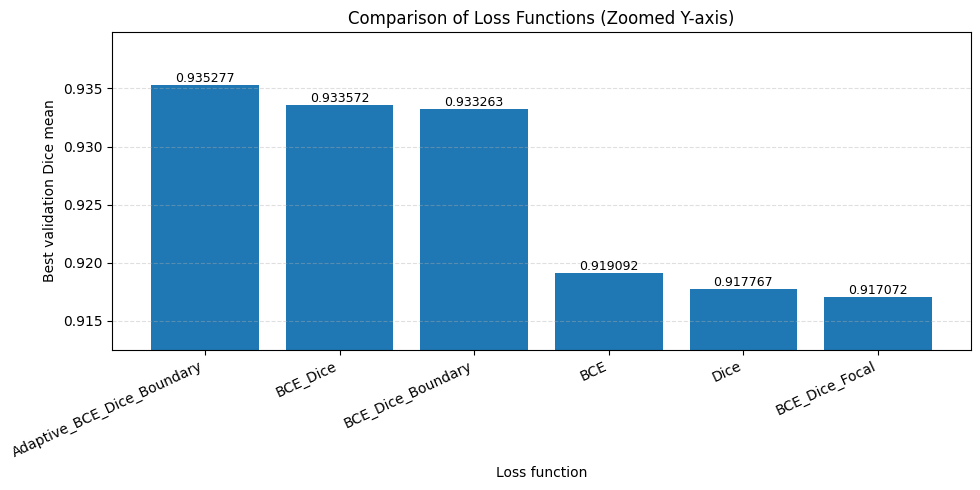

[Saved] /content/drive/MyDrive/論文_0422/loss_experiments/figures/loss_comparison_zoomed_dice.png


In [3]:
# ============================================================
# Plot loss_experiment_summary.csv
# 放大 Dice 差距：zoomed bar plot
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = Path("/content/drive/MyDrive/論文_0422/loss_experiments/loss_experiment_summary.csv")
OUT_DIR = CSV_PATH.parent / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# 自動找 Dice 欄位
possible_cols = ["best_dice_mean", "dice_mean", "val_dice_mean", "best_val_dice_mean"]
dice_col = None
for c in possible_cols:
    if c in df.columns:
        dice_col = c
        break

if dice_col is None:
    raise ValueError(f"找不到 Dice 欄位，目前欄位有：{list(df.columns)}")

# 自動找 loss 名稱欄位
possible_name_cols = ["name", "loss_name", "experiment", "loss", "config_name"]
name_col = None
for c in possible_name_cols:
    if c in df.columns:
        name_col = c
        break

if name_col is None:
    raise ValueError(f"找不到 loss 名稱欄位，目前欄位有：{list(df.columns)}")

# 排序：由高到低
plot_df = df[[name_col, dice_col]].copy()
plot_df = plot_df.sort_values(dice_col, ascending=False).reset_index(drop=True)

print(plot_df)

# -------------------------
# 放大 y 軸差距
# -------------------------
y_min = plot_df[dice_col].min()
y_max = plot_df[dice_col].max()

# 預留一點上下空間
margin = max((y_max - y_min) * 0.25, 0.002)
ylim_low = y_min - margin
ylim_high = y_max + margin

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df[name_col],
    plot_df[dice_col]
)

plt.ylim(ylim_low, ylim_high)
plt.ylabel("Best validation Dice mean")
plt.xlabel("Loss function")
plt.title("Comparison of Loss Functions (Zoomed Y-axis)")

plt.xticks(rotation=25, ha="right")

# 顯示數值
for bar, val in zip(bars, plot_df[dice_col]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

out_path = OUT_DIR / "loss_comparison_zoomed_dice.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("[Saved]", out_path)

In [6]:
# ============================================================
# 輸出 5 張：原圖 + 標註後圖片 overlay
# 使用 dataset mask：
#   masks_zp_inner
#   masks_embryo_outer
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ORI_DIR = Path("/content/drive/MyDrive/論文_new/need_label_ori")
ZP_MASK_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/masks_zp_inner")
EMB_MASK_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/masks_embryo_outer")

OUT_DIR = Path("/content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/check_original_overlay_5")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_SHOW = 10
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def collect_by_stem(folder: Path):
    files = []
    for ext in IMG_EXTS:
        files += list(folder.rglob(f"*{ext}"))
        files += list(folder.rglob(f"*{ext.upper()}"))
    return {p.stem: p for p in files}

def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_mask(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise ValueError(f"Cannot read mask: {path}")
    return m

def resize_mask(mask, h, w):
    return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

def make_overlay(img, zp_mask, emb_mask, alpha=0.35):
    overlay = img.copy()

    zp_bin = zp_mask > 127
    emb_bin = emb_mask > 127

    # zp_inner：紅色
    overlay[zp_bin] = (
        overlay[zp_bin] * (1 - alpha) + np.array([255, 0, 0]) * alpha
    ).astype(np.uint8)

    # embryo_outer：藍色
    overlay[emb_bin] = (
        overlay[emb_bin] * (1 - alpha) + np.array([0, 80, 255]) * alpha
    ).astype(np.uint8)

    # 畫輪廓
    zp_contours, _ = cv2.findContours(zp_bin.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    emb_contours, _ = cv2.findContours(emb_bin.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.drawContours(overlay_bgr, zp_contours, -1, (0, 0, 255), 2)      # red
    cv2.drawContours(overlay_bgr, emb_contours, -1, (255, 80, 0), 2)    # blue-ish
    overlay = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    return overlay

ori_map = collect_by_stem(ORI_DIR)
zp_map = collect_by_stem(ZP_MASK_DIR)
emb_map = collect_by_stem(EMB_MASK_DIR)

common_stems = sorted(set(ori_map) & set(zp_map) & set(emb_map))

print("[INFO] 原圖數量 =", len(ori_map))
print("[INFO] zp_inner mask 數量 =", len(zp_map))
print("[INFO] embryo_outer mask 數量 =", len(emb_map))
print("[INFO] 三者同檔名數量 =", len(common_stems))

if len(common_stems) == 0:
    raise RuntimeError("找不到同檔名資料，請確認原圖與 mask 檔名 stem 是否一致。")

selected = common_stems[:N_SHOW]
print("[INFO] 輸出檔名 =", selected)

for stem in tqdm(selected, desc="Saving original + overlay"):
    img = read_rgb(ori_map[stem])
    zp = read_mask(zp_map[stem])
    emb = read_mask(emb_map[stem])

    h, w = img.shape[:2]
    zp = resize_mask(zp, h, w)
    emb = resize_mask(emb, h, w)

    overlay = make_overlay(img, zp, emb)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Annotation Overlay\nred: zp_inner, blue: embryo_outer")
    axes[1].axis("off")

    plt.tight_layout()

    out_path = OUT_DIR / f"{stem}_original_overlay.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

print("[DONE] 已輸出到：", OUT_DIR)

[INFO] 原圖數量 = 100
[INFO] zp_inner mask 數量 = 100
[INFO] embryo_outer mask 數量 = 100
[INFO] 三者同檔名數量 = 100
[INFO] 輸出檔名 = ['1DD-D5(BEFORE5-4C)-20210502102450', '2BB-D5(BEFORE2-6C)-20210202155045', '2BB-D5(BEFORE4-4C)-20200414152103', '2BB-D5(BEFORE7-3C)-20180716154108', '2BB-D5(BEFORE9-1C)-20190910163556', '2BB-D5(BEFORE9-1C)-20200906093519', '2BB-D5(Before 5-2C)-20190530141927', '2BB-D5(Before 7-3C)-20180709141610', '2BC-D5(BEFORE7-1C)-20210728142612', '2BC-D5(BEFORE8-1C)-20190813124005']


Saving original + overlay:   0%|          | 0/10 [00:00<?, ?it/s]

[DONE] 已輸出到： /content/drive/MyDrive/論文_0422/zp_seg_dataset_ratio/check_original_overlay_5
